In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import boto3
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog

In [ ]:
from srm.config import setup_cluster

client = setup_cluster()
client

[2026-06-30 08:49:38,189][INFO    ][coiled] Fetching latest package priorities...
[2026-06-30 08:49:38,191][INFO    ][coiled.package_sync] Resolving your local /Users/shaneloeffler/dev/carbonplan/srm-downscaling/uv.lock Python environment...
[2026-06-30 08:49:38,384][INFO    ][coiled.package_sync] Scanning 283 python packages...
[2026-06-30 08:49:38,769][INFO    ][coiled] Running pip check...
[2026-06-30 08:49:39,211][INFO    ][coiled] Validating environment...
[2026-06-30 08:49:39,885][INFO    ][coiled] Creating wheel for ~/dev/carbonplan/srm-downscaling/src...
[2026-06-30 08:49:39,892][INFO    ][coiled] Creating wheel for srm...
[2026-06-30 08:49:39,896][INFO    ][coiled] Uploading coiled_local_src...
[2026-06-30 08:49:40,913][INFO    ][coiled] Uploading srm...
[2026-06-30 08:49:41,862][INFO    ][coiled] Creating software environment...
[2026-06-30 08:49:42,685][INFO    ][coiled] Creating Cluster (name: carbonplan-cb81db60, https://cloud.coiled.io/clusters/1774550 ). This usually tak

Connection method: Cluster object,Cluster type: coiled.Cluster
Dashboard: https://cluster-ooajq.dask.host/uBI9HP1va4DWZTh2/status,
Dashboard: https://cluster-ooajq.dask.host/uBI9HP1va4DWZTh2/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tls://10.1.49.119:8786,Workers: 0
Dashboard: http://10.1.49.119:8788/status,Total threads: 0
Started: Just now,Total memory: 0 B


[2026-06-30 08:51:41,275][INFO    ][coiled] Adaptive scaling up to 2 workers.
[2026-06-30 08:55:31,340][INFO    ][coiled] Adaptive is removing 1 workers.


In [28]:
def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [29]:
def resolve_s3_glob(path):
    """Resolve a single * wildcard in an S3 path to a real path."""
    bucket, prefix = path.replace("s3://", "").split("/", 1)

    before, after = prefix.split("*/", 1)

    s3 = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=before, Delimiter="/")

    matches = [f"s3://{bucket}/{cp['Prefix']}{after}" for cp in response.get("CommonPrefixes", [])]

    if not matches:
        raise ValueError(f"No S3 paths matched: {path}")
    if len(matches) > 1:
        raise ValueError(f"Multiple matches: {matches}")

    return matches[0]

In [30]:
ds_dict = {
    "historical": catalog.get("CESM2-WACCM-historical-icechunk")
    .to_xarray()
    .sel(time=slice("1978", "2014")),
    "ssp2-4.5": catalog.get("CESM2-WACCM-SSP245-icechunk")
    .to_xarray()
    .sel(time=slice("2015", "2100")),
    "g6-1.5k": catalog.get("CESM2-WACCM-G6-1.5K-icechunk")
    .to_xarray()
    .sel(time=slice("2035", "2085")),
}

In [31]:
def complete_annual_mean(series, min_days=360):
    """Annual mean over the years each ensemble member individually covers.

    Masks any (member, year) with fewer than ``min_days`` valid days, so partial
    years (staggered ensemble end dates, mid-year run ends) drop out instead of
    collapsing into a spurious single-day mean. Each member is kept to its own
    last complete year, so a ragged ensemble (SSP245 members 006-010 end ~2070
    while 001-005 run to 2100) thins out rather than being cut to the shortest.
    """
    valid_days = series.notnull().groupby("time.year").sum()
    return series.groupby("time.year").mean().where(valid_days >= min_days)

In [32]:
dfs = []
for scenario, ds in ds_dict.items():
    series = ds.tas.weighted(np.cos(np.deg2rad(ds.lat))).mean(dim=["lat", "lon"])
    _df = (
        complete_annual_mean(series)
        .rename("value")
        .to_dataframe()
        .reset_index()
        .dropna(subset=["value"])
    )
    _df["scenario"] = scenario
    _df["gcm"] = str(ds.model)
    _df["variable"] = "tas_global"
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)[
    ["year", "scenario", "ensemble_member", "gcm", "variable", "value"]
]

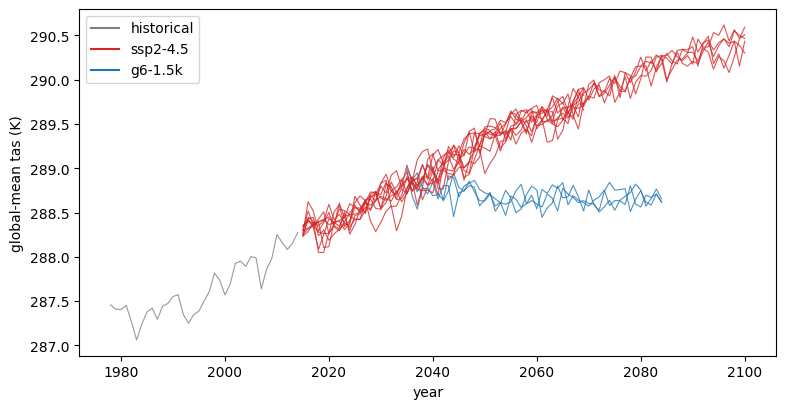

In [33]:
colors = {"historical": "0.5", "ssp2-4.5": "tab:red", "g6-1.5k": "tab:blue"}

fig, ax = plt.subplots(figsize=(9, 4.5))
for (scenario, member), group in df.groupby(["scenario", "ensemble_member"]):
    ax.plot(group.year, group.value, color=colors[scenario], lw=0.8, alpha=0.8)
for scenario, color in colors.items():
    ax.plot([], [], color=color, label=scenario)  # legend proxies (one entry per scenario)
ax.set(xlabel="year", ylabel="global-mean tas (K)")
ax.legend()

In [34]:
df

,year,scenario,ensemble_member,gcm,variable,value
0,1978,historical,001,CESM2-WACCM,tas_global,287.459145
1,1979,historical,001,CESM2-WACCM,tas_global,287.408345
2,1980,historical,001,CESM2-WACCM,tas_global,287.407021
3,1981,historical,001,CESM2-WACCM,tas_global,287.451691
4,1982,historical,001,CESM2-WACCM,tas_global,287.270656
...,...,...,...,...,...,...
887,2080,g6-1.5k,003,CESM2-WACCM,tas_global,288.562371
888,2081,g6-1.5k,003,CESM2-WACCM,tas_global,288.696412
889,2082,g6-1.5k,003,CESM2-WACCM,tas_global,288.672728
890,2083,g6-1.5k,003,CESM2-WACCM,tas_global,288.708450


In [35]:
df.to_csv("s3://carbonplan-srm/output/explainer/figures/figure2.csv")

In [36]:
# Shut the Coiled cluster down